# Normative Modelling: Hierarchical Bayesian Regression with SHASH likelihood

Welcome to this tutorial notebook that will go through the fitting and evaluation of Normative models with a Hierarchical Bayesian Regression model using a SHASH likelihood. 

Let's jump right in.


### Imports

In [ ]:
!pip install pcntoolkit

In [1]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    SHASHbLikelihood,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

First we download a small example dataset from github.

### The fcon1000 dataset

The fcon1000 dataset is a publicly available multi-site neuroimaging dataset containing structural MRI measures from healthy control subjects. For this tutorial we use a subset with four brain features:

- **WM-hypointensities** — volume of white matter signal abnormalities; heavily right-skewed, increases with age
- **Right-Lateral-Ventricle** — volume of the right lateral ventricle; also right-skewed and heteroskedastic
- **Right-Amygdala** — volume of the right amygdala; approximately Gaussian
- **CortexVol** — total cortical grey matter volume; approximately Gaussian

These four features are deliberately chosen to span a range of distributional shapes — from well-behaved (CortexVol, Right-Amygdala) to highly non-Gaussian (WM-hypointensities). This will let us see clearly where a Gaussian model fails and where the SHASH extension helps.

The dataset spans roughly ages 5–85 and is collected across multiple scanner sites. Site and sex are recorded as batch effects.

In [ ]:
# Download an example dataset
norm_data: NormData = load_fcon1000()

In [ ]:
# Inspect the normdata object
norm_data 

### The NormData object

`NormData` is PCNtoolkit's core data container. It is built on top of `xarray` and organises everything the model needs in one place:

| Attribute | What it contains |
|---|---|
| `Y` | Response variables — the brain features we want to model |
| `X` | Covariates — age (and optionally sex) used to predict Y |
| `batch_effects` | Nuisance variables — site, sex — used to model or remove scanner differences |
| `Z` | Z-scores — filled in after fitting; how many standard deviations each subject is from the normative mean |

A few useful methods:
- `norm_data.sel({"response_vars": [...]})` — select a subset of features
- `norm_data.train_test_split()` — split into train and test sets
- `norm_data.to_dataframe()` — convert to a pandas DataFrame for plotting
- `test.get_statistics_df()` — after fitting, returns evaluation metrics (R², RMSE, Shapiro-W, etc.) per feature

The cell below loads the data, selects our four features, and splits into train/test. Run it and then inspect `train` by typing `train` in a new cell — the xarray representation will show you the dimensions and coordinates directly.

In [ ]:
# Select only a few features to model
features_to_model = [
    "WM-hypointensities",
    "Right-Lateral-Ventricle",
    "Right-Amygdala",
    "CortexVol",
]
norm_data = norm_data.sel({"response_vars": features_to_model})

# Split into train and test sets
train, test = norm_data.train_test_split()

Next, we visualize one of the features, just to see what it looks like.

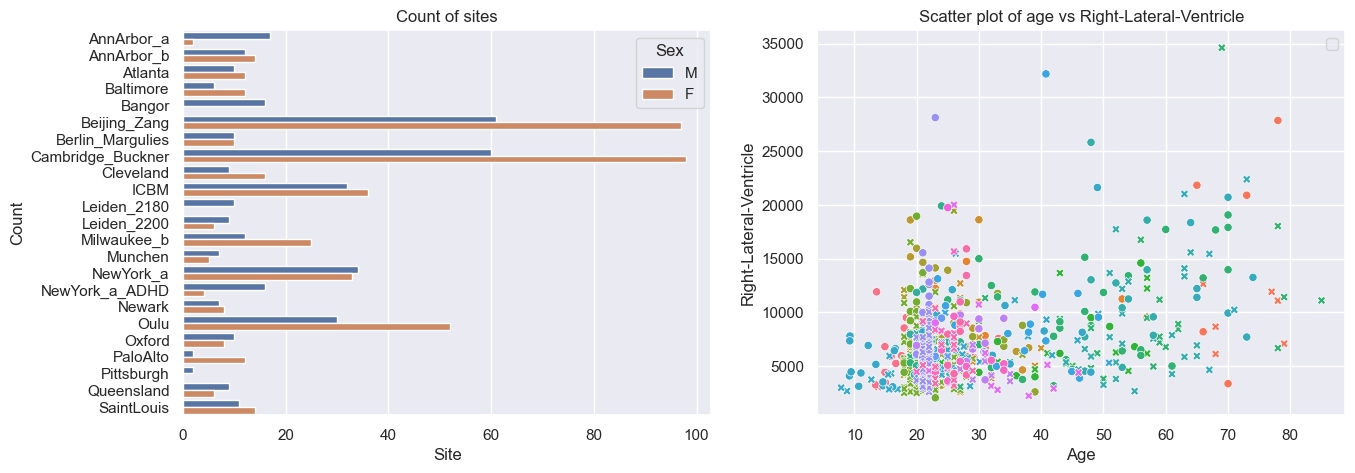

In [3]:
# Visualize the data
feature_to_plot = features_to_model[1]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

**What to look for in these plots:**

The count plot on the left shows how many subjects come from each site, split by sex. Notice the large imbalance — some sites have hundreds of subjects, others just a handful. This is exactly why partial pooling matters: a model that treats all sites equally will give noisy, unreliable estimates for the small sites.

The scatter plot on the right shows the raw age–feature relationship for WM-hypointensities. Notice the strong right skew (a few subjects have very high values) and the increasing spread with age (heteroskedasticity). Both of these will cause problems for a Gaussian normative model, as we will see shortly.

## Creating a Normative model

A normative model has a regression model for each response variable. We provide a template regression model which is copied for each response variable. 

A template regression model can be anything that extends the `RegressionModel`. We provide a number of built-in regression models, but you can also create your own. 

Here we use the `HBR` class, which implements a Hierarchical Bayesian Regression model. 


### Likelihoods

`HBR` models are composed of a likelihood and a number of priors on the parameters of the likelihood. The PCNtoolkit offers a number of likelihood functions:
1. NormallLikelihood: Good for modeling data that is (approximately) normally distributed.
2. SHASHbLikelihood: Good for modeling data that is heavily skewed, or tailed. 
3. BetaLikelihood: Good for modeling data that is bounded, e.g. between 0 and 1.

### Likelihood parameters

Each of these likelihoods takes their own set of parameters, and for each, we have to set a prior:
1. NormalLikelihood:
    - `mu`: The mean of the normal distribution.
    - `sigma`: The standard deviation of the normal distribution.
2. SHASHbLikelihood:
    - `mu`: The mean of the skew-normal distribution.
    - `sigma`: The standard deviation of the skew-normal distribution.
    - `epsilon`: The skewness parameter of the skew-normal distribution.
    - `delta`: The tail thickness (or kurtosis) of the skew-normal distribution.
3. BetaLikelihood:
    - `alpha`: The shape parameter of the beta distribution.
    - `beta`: The scale parameter of the beta distribution.

### Configuring likelihood parameters

Each likelihood parameter needs to be configured. The defaults should work reasonably well for most cases, at least where the data is standardized. Here's a quick guide to configuring the likelihood parameters yourself, using the `make_prior` function.

1. Is your parameter a function of the covariates? If so, you set the `linear` parameter to `True`.
   1. If so, you can choose the basis expansion to use for the parameter: BSplineBasisFunction, LinearBasisFunction, or PolynomialBasisFunction.
   2. Also, determine whether the slope and intercept of the prior have a random effect or not. Here's an example of a linear prior with a bspline basis expansion and a random effect in the intercept. 

```python
mu = make_prior('mu', linear=True, basis_function=BSplineBasisFunction(degree=3, nknots=5), intercept = make_prior('intercept_mu', random=True))
```

2. If your parameter is not a function of the covariates, you have to decide whether the parameter itself has a random effect or not. Here's an example of a prior with a random effect.

```python
epsilon = make_prior('epsilon', random=True)
```

3. Some parameters (such as sigma) need to be strictly positive, which we can enforce with a mapping. Here's an example of a prior with a mapping to the positive real line.

```python
# The mapping_params are (horizontal shift, scaling, vertical shift)
sigma = make_prior('sigma', mapping='softplus', mapping_params=(0, 5, 0))
```

In [ ]:
# Mini demo of the mapping params
xsp = np.linspace(-7, 7, 100)
softplus = lambda x: np.log(1 + np.exp(x))
paramaterized_softplus = lambda x, a, b, c: softplus((x - a) / b) * b + c
plt.plot(xsp, paramaterized_softplus(xsp, 0, 1, 0), label="no mapping")
plt.plot(xsp, paramaterized_softplus(xsp, 1.5, 1, 0), label="horizontal shift of 1.5")
plt.plot(xsp, paramaterized_softplus(xsp, 0, 1, 1), label="vertical shift of 1")
plt.plot(xsp, paramaterized_softplus(xsp, 0, 2, 0), label="scale with a factor of 2")
plt.legend()
plt.show()

4. Any non-linear parameters can be further configured with `dist_name` and `dist_params`. Here's an example of a prior with a gamma distribution. 

```python
alpha = make_prior('alpha', dist_name='gamma', dist_params=(1, 1))
```
We currently support the following distributions:
- Normal
- HalfNormal
- LogNormal
- Uniform
- Gamma
  
The order of the parameters is important, and follows the order of the parameters in the corresponding distributions in PyMC.

## Step 1 — Gaussian baseline

Before introducing the SHASH distribution, we fit a simpler model with a **Normal likelihood**. This gives us a baseline to compare against, and lets us clearly see *why* the Gaussian assumption fails for skewed phenotypes.

**Question to consider:** Look at the features we selected — `WM-hypointensities`, `Right-Lateral-Ventricle`, `Right-Amygdala`, `CortexVol`. Which of these do you expect to be most non-Gaussian, and why?

In [4]:
# Step 1: Gaussian HBR — the simplest possible model
# mu is linear in age with a random (site-specific) intercept
# sigma is linear in age, shared across sites
# No skewness or kurtosis parameters

mu_gauss = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0),
                         mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_gauss = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

gaussian_regression_model = HBR(
    name="gaussian_template",
    cores=4,
    progressbar=True,
    draws=1000,
    tune=500,
    chains=2,
    nuts_sampler="nutpie",
    likelihood=NormalLikelihood(mu_gauss, sigma_gauss),
)

gaussian_model = NormativeModel(
    template_regression_model=gaussian_regression_model,
    savemodel=False,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir="resources/step1_gaussian",
    inscaler="standardize",
    outscaler="standardize",
)

gaussian_model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,63
,1500,0,0.13,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.12,31
,1500,0,0.14,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,31
,1500,0,0.14,95


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,255
,1500,0,0.14,31


<xarray.NormData> Size: 98kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 11)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.5531 ... -...
    centiles           (centile, observations, response_vars) float64 35kB -5...
    logp               (observations, response_vars) float64 7kB -1.709 ... -...
    Yhat               (observations, response_vars) float64 7kB 1.904e+03 .....
    statistics         (response_vars, statistic) float64 352B 0.3601 ... 0.9947
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): [np.str_('F'), np.str_('...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(28.2...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('F'): {np.str_(...

=== Centile curves (Gaussian model) ===


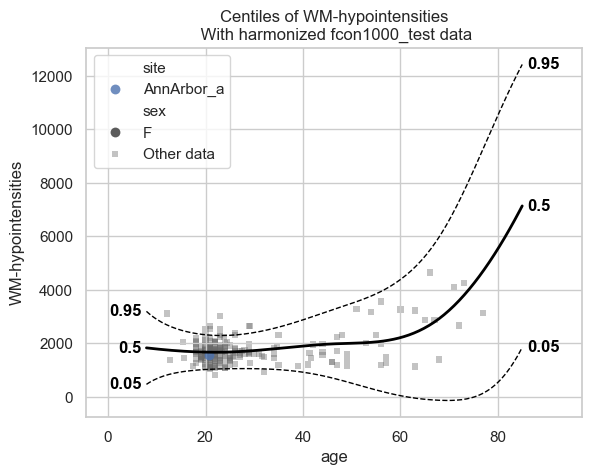

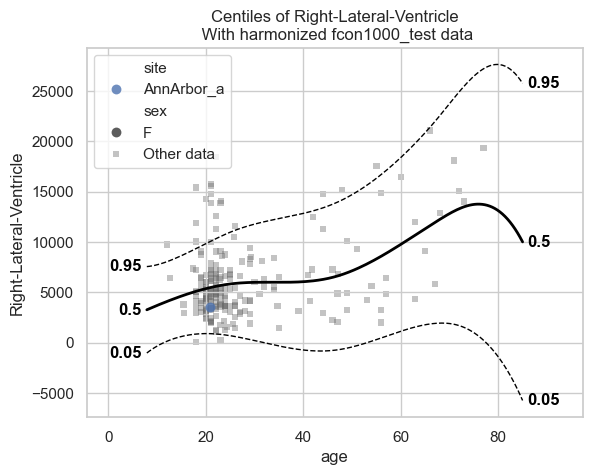

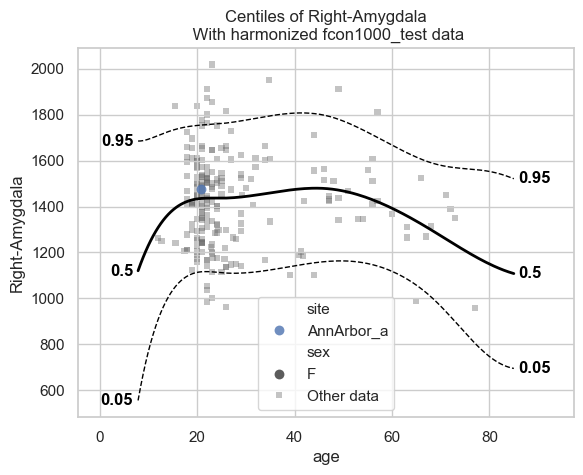

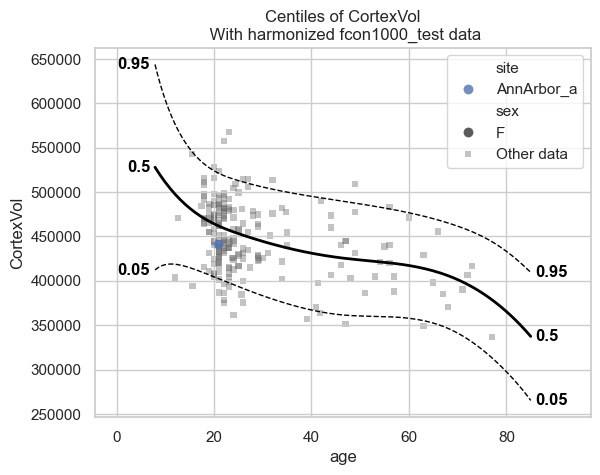


=== QQ plots (Gaussian model) ===


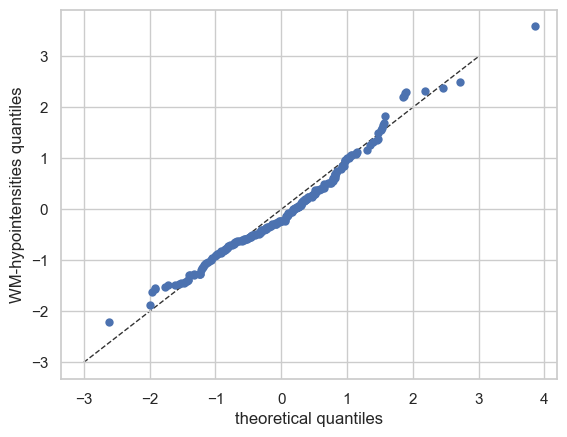

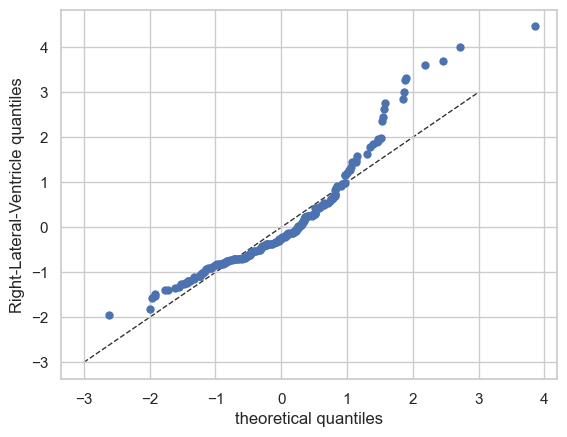

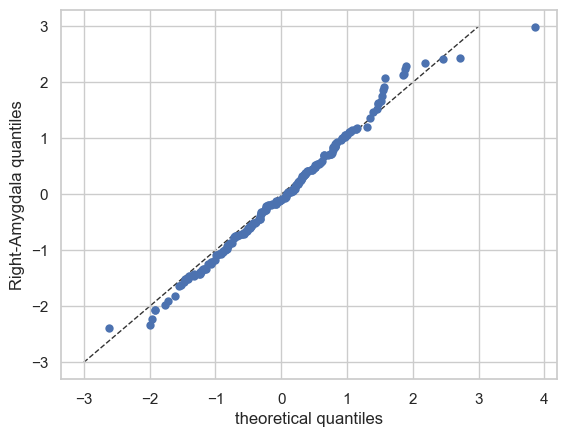

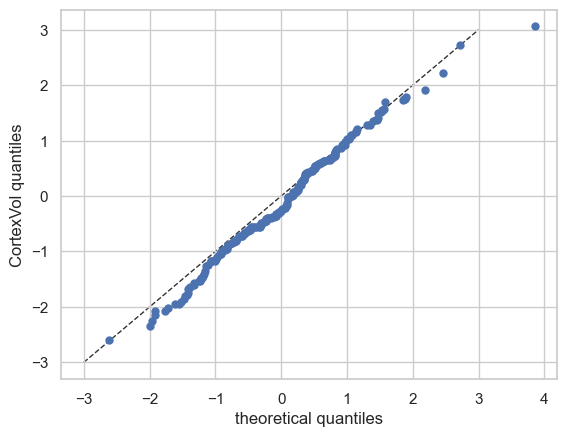

In [5]:
# Inspect the Gaussian fit: centile curves and QQ plots
# Pay attention to how well the curves track the data for each feature.
# WM-hypointensities in particular should look bad.

print("=== Centile curves (Gaussian model) ===")
plot_centiles_advanced(
    gaussian_model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=test,
    show_other_data=True,
    harmonize=True,
)

print("\n=== QQ plots (Gaussian model) ===")
plot_qq(test, plot_id_line=True)

Look at the centile plots and QQ plots. Do you think the fit is good? 
Why? Why not?

In [6]:
# Print the moment statistics for the Gaussian model
# Skew and excess kurtosis of z-scores should be close to 0 for a good fit.
# Values far from 0 indicate the model is not capturing the data distribution.

print("Training set statistics (Gaussian):")
display(train.get_statistics_df())
print("\nTest set statistics (Gaussian):")
display(test.get_statistics_df())

Training set statistics (Gaussian):


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.519610,0.012111,0.057243,-11.211266,1.069306,0.519609,36136.398745,0.710654,1.785137e-133,0.480391,0.995850
Right-Amygdala,0.387490,0.014849,0.087537,-5.732169,1.188026,0.387490,191.744160,0.605277,2.780193e-87,0.612510,0.990698
Right-Lateral-Ventricle,0.241033,0.046636,0.380269,-8.441017,1.233807,0.241033,3354.260407,0.387223,3.211945e-32,0.758967,0.871636
WM-hypointensities,0.358907,0.049652,0.306824,-7.254690,0.869530,0.358906,653.924294,0.505677,3.788755e-57,0.641094,0.881973



Test set statistics (Gaussian):


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.420982,0.025926,0.063509,-11.114493,1.103067,0.412896,37509.331443,0.642463,1.545115e-26,0.587104,0.994712
Right-Amygdala,0.290545,0.014815,0.094863,-5.655117,1.227409,0.289549,198.871678,0.506638,1.744087e-15,0.710451,0.991558
Right-Lateral-Ventricle,0.204278,0.050926,0.421639,-8.340823,1.349683,0.203516,3490.475447,0.265320,7.889095e-05,0.796484,0.889695
WM-hypointensities,0.360051,0.037037,0.341827,-7.026159,0.798391,0.357004,485.317625,0.492443,1.354270e-14,0.642996,0.967340


**What to look for:** For `WM-hypointensities` and `Right-Lateral-Ventricle`, you should see:
- Centile curves that dip below zero (impossible for a volume measure)
- QQ plots with curved tails — the empirical quantiles deviate from the theoretical Gaussian line
- Large skew and excess kurtosis values in the statistics table

This motivates the SHASH extension. Keep these plots open as a reference.

## Step 2 — SHASH with constant parameters

Now we swap the Gaussian likelihood for `SHASHbLikelihood`, but keep **all four parameters as simple constants** — no age-dependence, no site effects on ε or δ. The only new thing is the SHASH distribution itself.

This isolates the effect of allowing skewness (ε) and tail thickness (δ) — we want to see how much improvement we get just from using a more flexible distribution, before adding any further complexity.

**Question:** The model samples a single ε and a single δ for the whole dataset. What does this assume about skewness across sites and across the lifespan?

In [7]:
# Step 2: SHASHb with all four parameters as fixed scalars
# mu and sigma still have the full hierarchical structure from Step 1
# epsilon and delta are single scalars — same for every subject, site, and age

mu_s2 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0),
                         mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_s2 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

# These are the new parameters — fixed scalars, one value for the entire dataset
epsilon_s2 = make_prior(
    dist_name="Normal",
    dist_params=(0.0, 1.0),   # prior centred at 0 = no assumed skew direction
)
delta_s2 = make_prior(
    dist_name="Normal",
    dist_params=(1.0, 1.0),
    mapping="softplus",
    mapping_params=(0.0, 3.0, 0.6),  # floor at 0.6 for numerical stability
)

shashb1_const_model_def = HBR(
    name="shashb1_const_template",
    cores=4,
    progressbar=True,
    draws=1000,
    tune=500,
    chains=2,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu_s2, sigma_s2, epsilon_s2, delta_s2),
)

shashb1_const_model = NormativeModel(
    template_regression_model=shashb1_const_model_def,
    savemodel=False,
    evaluate_model=True,
    saveresults=False,
    saveplots=False,
    save_dir="resources/step2_shash_const",
    inscaler="standardize",
    outscaler="standardize",
)

shashb1_const_model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,511
,1500,0,0.02,1023


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,511
,1500,0,0.01,1023


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,511
,1500,0,0.01,1023


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.02,1023
,1500,0,0.02,1023


<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.5285 ... -...
    logp               (observations, response_vars) float64 7kB -1.626 ... -...
    Yhat               (observations, response_vars) float64 7kB 2.354e+03 .....
    statistics         (response_vars, statistic) float64 352B 0.393 ... 0.995
    Y_harmonized       (observations, response_vars) float64 7kB 3.224e+03 .....
    centiles           (centile, observations, response_vars) float64 35kB 1....
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): [np.str_('F'), np.str_('...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(28.2...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('F'): {np.str_(...

=== Centile curves (SHASHb, constant ε and δ) ===


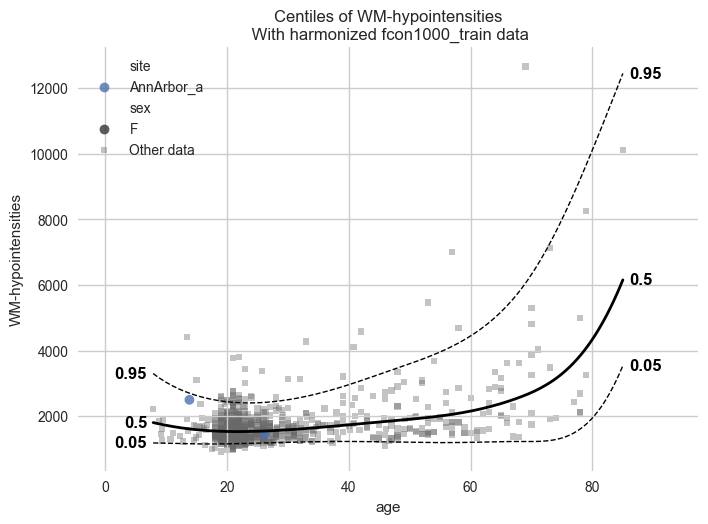

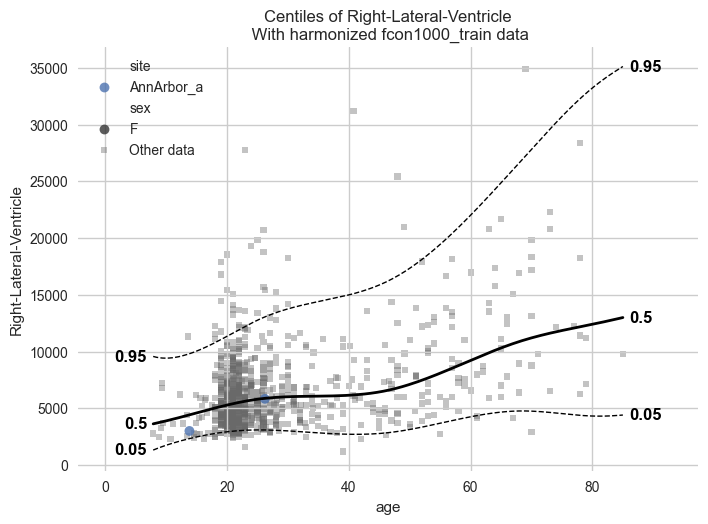

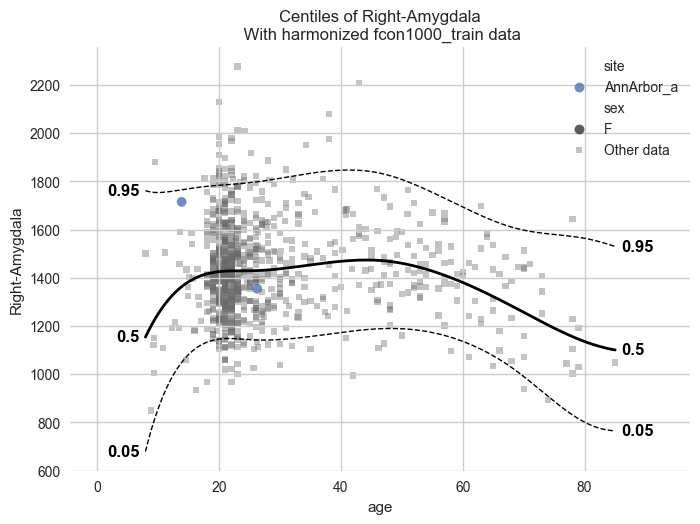

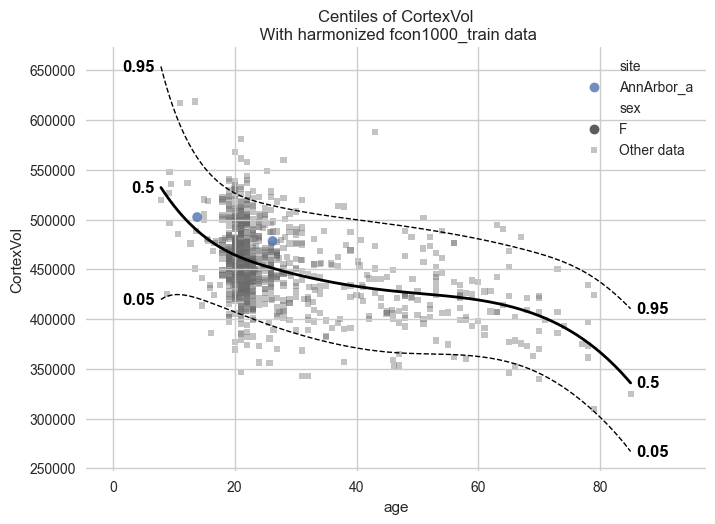


=== QQ plots (SHASHb, constant ε and δ) ===


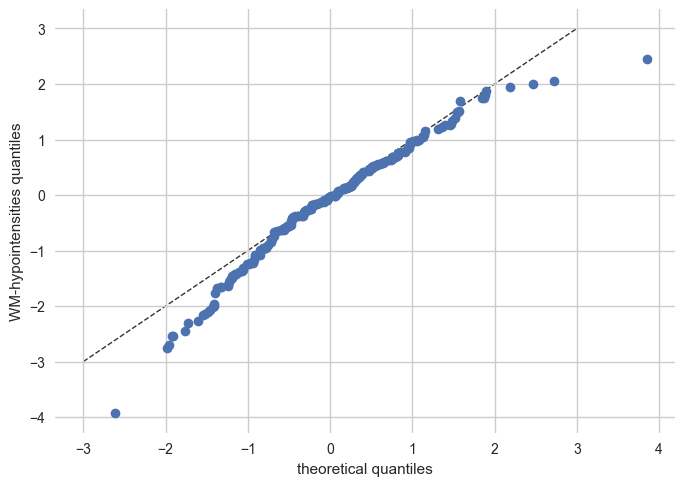

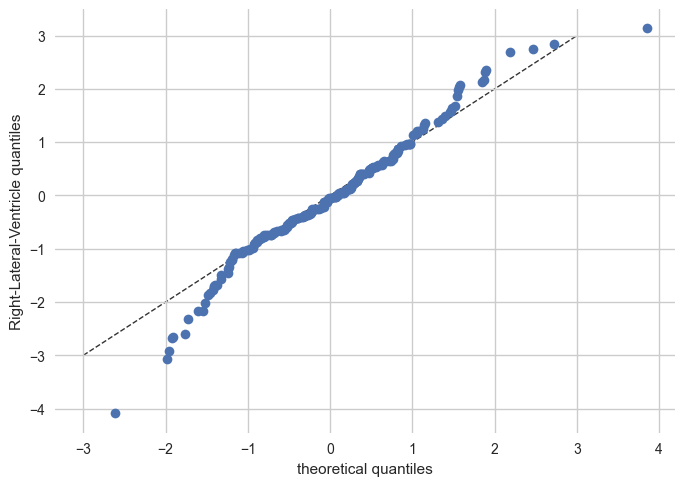

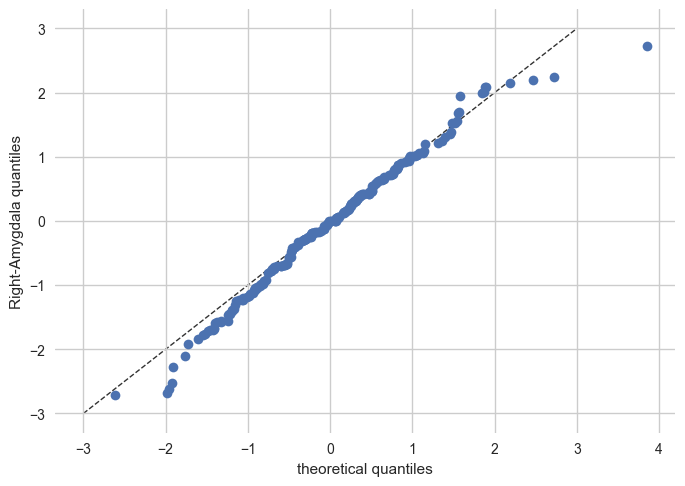

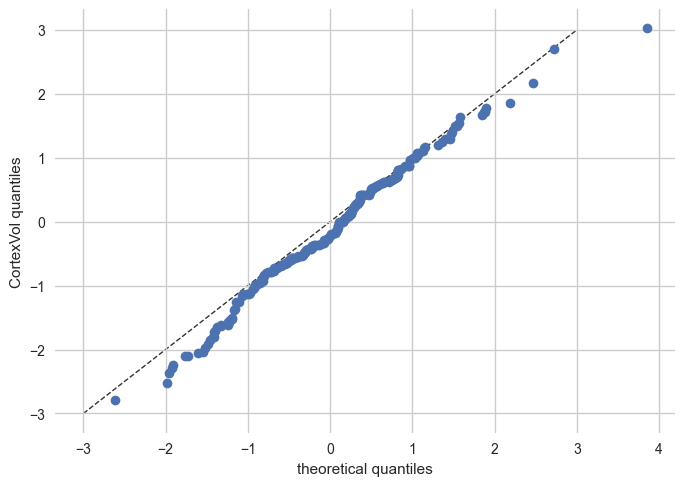


Test set statistics (SHASHb constant):


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.421680,0.026852,0.063443,-11.112280,1.105280,0.412739,37514.345412,0.641788,1.811247e-26,0.587261,0.994965
Right-Amygdala,0.302120,0.017037,0.094712,-5.663117,1.219409,0.300326,197.357581,0.523230,1.403924e-16,0.699674,0.991744
Right-Lateral-Ventricle,0.226241,0.016111,0.431265,-8.529040,1.161466,0.226136,3440.553662,0.262012,9.749931e-05,0.773864,0.984954
WM-hypointensities,0.391928,0.018519,0.347843,-7.076443,0.748107,0.383072,475.377929,0.513214,6.531231e-16,0.616928,0.980891


In [25]:
# Compare centile curves and QQ plots with the Gaussian model
# The SHASH centiles should now stay positive for volume measures.

print("=== Centile curves (SHASHb, constant ε and δ) ===")
plot_centiles_advanced(
    shashb1_const_model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=train,
    harmonize=True,
    show_other_data=True
)

print("\n=== QQ plots (SHASHb, constant ε and δ) ===")
plot_qq(test, plot_id_line=True)

print("\nTest set statistics (SHASHb constant):")
display(test.get_statistics_df())

**What to look for:**
- The lower centile for `WM-hypointensities` should no longer dip below zero
- QQ plots should be straighter than the Gaussian model
- Skew and excess kurtosis in the statistics table should be closer to 0

The fitted ε and δ values are available in the model trace. A positive ε means right skew; δ < 1 means heavier tails than Gaussian.

## Step 3 — Add age-varying σ (heteroskedasticity)

In Step 2, σ was already linear in age. But let's make this concrete by examining what heteroskedasticity looks like in the data, and confirming that the model captures it.

**Question:** For `Right-Lateral-Ventricle`, does variance increase or decrease with age? Can you see this in the scatter plot from the data visualisation cell above?

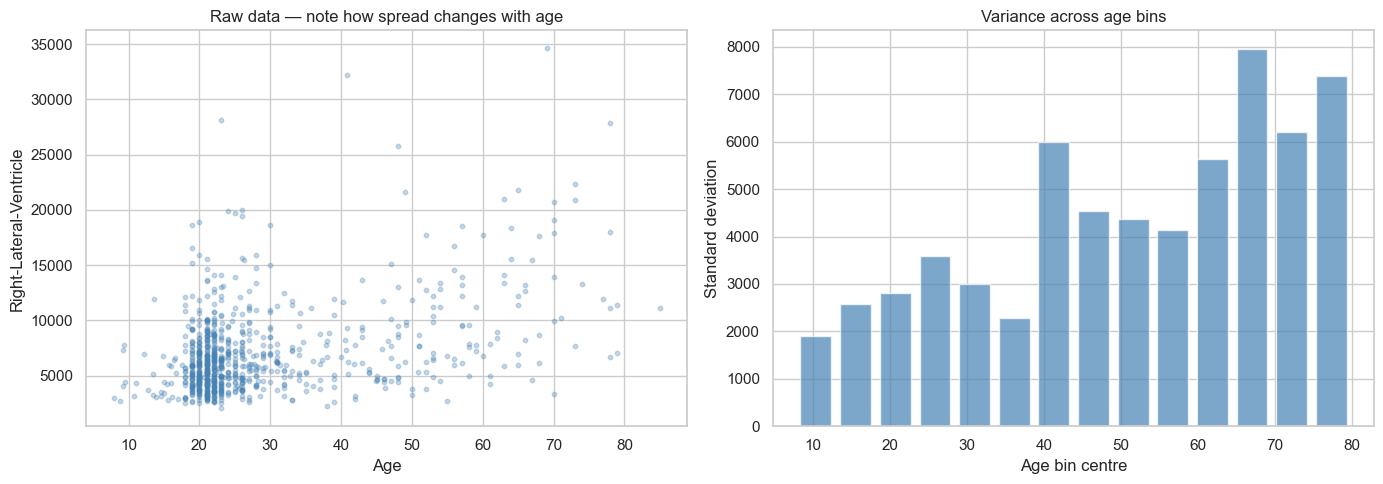

In [10]:
# Visualise heteroskedasticity explicitly before fitting
# We plot the raw data and overlay a rolling standard deviation to show
# how variance changes across the age range.

feature_to_examine = "Right-Lateral-Ventricle"
df_train = train.to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scatter
axes[0].scatter(
    df_train[("X", "age")],
    df_train[("Y", feature_to_examine)],
    alpha=0.3, s=10, color="steelblue"
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel(feature_to_examine)
axes[0].set_title("Raw data — note how spread changes with age")

# Rolling std across age bins
age_bins = pd.cut(df_train[("X", "age")], bins=15)
rolling_std = df_train[("Y", feature_to_examine)].groupby(age_bins).std()
bin_centres = [(b.left + b.right) / 2 for b in rolling_std.index]
axes[1].bar(bin_centres, rolling_std.values, width=4, color="steelblue", alpha=0.7)
axes[1].set_xlabel("Age bin centre")
axes[1].set_ylabel("Standard deviation")
axes[1].set_title("Variance across age bins")

plt.tight_layout()
plt.show()

## Step 4 — The full S_b1 model

We now have all the pieces. The full model from the notebook is exactly what we've been building:

- **μ**: linear in age (B-spline), random site/sex intercept → captures trajectory + site effects  
- **σ**: linear in age (B-spline), fixed intercept → captures heteroskedasticity  
- **ε**: fixed scalar → one skewness value for the whole dataset  
- **δ**: fixed scalar with floor at 0.6 → one tail-thickness value for the whole dataset  

This is the S_b1 model from the paper (Table 1). Run it and compare carefully against the Gaussian baseline.



### Creating a HBR model

Here's a thoroughly commented example of a HBR model with a SHASH Likelihood, which we will use to model our response variable.

In [28]:
# The SHASHb likelihood is a bit more flexible than the Normal likelihood, and takes four parameters, mu, sigma, epsilon, and delta.
# Mu and sigma fulfill the same role as in the Normal likelihood, namely the mean and standard deviation of the distribution.
# Epsilon and delta are parameters that control the skewness and kurtosis of the distribution.

# SHASHb model with fixed values for epsilon and delta

mu = make_prior(
    # Mu is linear because we want to allow the mean to vary as a function of the covariates.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 10.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    # The intercept is random, because we expect the intercept to vary between sites and sexes.
    intercept=make_prior(
        random=True,
        # Mu is the mean of the intercept, which is normally distributed with a mean of 0 and a standard deviation of 1.
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        # Sigma is the scale at which the intercepts vary. It is a positive parameter, so we have to map it to the positive domain.
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0), mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    # We use a B-spline basis function to allow for non-linearity in the mean.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    # Sigma is also linear, because we want to allow the standard deviation to vary as a function of the covariates: heteroskedasticity.
    linear=True,
    # The slope coefficients are assumed to be normally distributed, with a mean of 0 and a standard deviation of 2.
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    # The intercept is not random, because we assume the intercept of the variance to be the same for all sites and sexes.
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    # We use a B-spline basis function to allow for non-linearity in the standard deviation.
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    # We use a softplus mapping to ensure that sigma is strictly positive.
    mapping="softplus",
    # We scale the softplus mapping by a factor of 3, to avoid spikes in the resulting density.
    # The parameters (a, b, c) provided to a mapping f are used as: f_abc(x) = f((x - a) / b) * b + c
    # This basically provides an affine transformation of the softplus function.
    # a -> horizontal shift
    # b -> scaling
    # c -> vertical shift
    # You can leave c out, and it will default to 0.
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    # Epsilon is assumed to follow a normal distribution, with a mean of 0 and a standard deviation of 1.
    dist_name="Normal",
    dist_params=(0.0, 1.0),
)

delta = make_prior(
    # Delta is sampled from a normal distribution, with a mean of 1 and a standard deviation of 1, and then mapped to the positive real line using a softplus function.
    dist_name="Normal",
    dist_params=(1.0, 1.0),
    mapping="softplus",
    # We apply a softplus mapping to the delta parameter, to ensure that it is strictly positive.
    mapping_params=(
        0.0,  # Horizontal shift
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb1_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)

After specifying the regression model, we can configure a normative model. 

A normative model has a number of configuration options:
- `savemodel`: Whether to save the model after fitting.
- `evaluate_model`: Whether to evaluate the model after fitting.
- `saveresults`: Whether to save the results after evaluation.
- `saveplots`: Whether to save the plots after fitting.
- `save_dir`: The directory to save the model, results, and plots.
- `inscaler`: The scaler to use for the input data.
- `outscaler`: The scaler to use for the output data.




In [ ]:
model = NormativeModel(
    # The regression model to use for the normative model.
    template_regression_model=shashb1_regression_model,
    # Whether to save the model after fitting.
    savemodel=True,
    # Whether to evaluate the model after fitting.
    evaluate_model=True,
    # Whether to save the results after evaluation.
    saveresults=True,
    # Whether to save the plots after fitting.
    saveplots=False,
    # The directory to save the model, results, and plots.
    save_dir="resources/hbr_SHASH/save_dir",
    # The scaler to use for the input data. Can be either one of "standardize", "minmax", "robminmax", "none"
    inscaler="standardize",
    # The scaler to use for the output data. Can be either one of "standardize", "minmax", "robminmax", "none"
    outscaler="standardize",
)

## Fit the model


With all that configured, we can fit the model. 

The `fit_predict` function will fit the model, evaluate it, and save the results and plots (if so configured). 

After that, it will compute Z-scores and centiles for the test set. 

All results can be found in the save directory. 

In [30]:
model.fit_predict(train, test)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,1023
,2000,0,0.02,1023
,2000,0,0.01,1023
,2000,0,0.01,255


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,1023
,2000,0,0.02,511
,2000,0,0.01,1023
,2000,0,0.01,511


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.01,511
,2000,0,0.01,1023
,2000,0,0.02,255
,2000,0,0.01,511


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.02,1023
,2000,0,0.01,511
,2000,0,0.01,1023
,2000,0,0.02,511


<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.5207 ... -...
    logp               (observations, response_vars) float64 7kB -1.621 ... -...
    Yhat               (observations, response_vars) float64 7kB 2.363e+03 .....
    statistics         (response_vars, statistic) float64 352B 0.3924 ... 0.995
    Y_harmonized       (observations, response_vars) float64 7kB 3.224e+03 .....
    centiles           (centile, observations, response_vars) float64 35kB 1....
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): [np.str_('F'), np.str_('...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(28.2...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('F'): {np.str_(...

## Step 5 — Structured comparison across models

Now that we have both the Gaussian and S_b1 models fitted, let's compare them systematically using the same metrics as in the paper (Table 3).

In [33]:
# Side-by-side statistics comparison: Gaussian vs SHASHb S_b1
# Skew and excess kurtosis of z-scores — closer to 0 is better.

import pandas as pd

print("=== Gaussian model (test set) ===")
gauss_stats = gaussian_model.predict(test)
display(test.get_statistics_df())

print("\n=== SHASHb S_b1 model (test set) ===")
model.predict(test)
display(test.get_statistics_df())

=== Gaussian model (test set) ===


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.420982,0.025926,0.063509,-11.114493,1.103067,0.412896,37509.331443,0.642463,1.545115e-26,0.587104,0.994712
Right-Amygdala,0.290545,0.014815,0.094863,-5.655117,1.227409,0.289549,198.871678,0.506638,1.744087e-15,0.710451,0.991558
Right-Lateral-Ventricle,0.204278,0.050926,0.421639,-8.340823,1.349683,0.203516,3490.475447,0.265320,7.889095e-05,0.796484,0.889695
WM-hypointensities,0.360051,0.037037,0.341827,-7.026159,0.798391,0.357004,485.317625,0.492443,1.354270e-14,0.642996,0.967340



=== SHASHb S_b1 model (test set) ===


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.421705,0.027778,0.063438,-11.112507,1.105053,0.412854,37510.674475,0.641378,1.994190e-26,0.587146,0.994963
Right-Amygdala,0.302427,0.017037,0.094723,-5.663425,1.219101,0.300587,197.320692,0.524126,1.220359e-16,0.699413,0.991760
Right-Lateral-Ventricle,0.226928,0.015185,0.431230,-8.529933,1.160573,0.226812,3439.050991,0.262759,9.296952e-05,0.773188,0.985097
WM-hypointensities,0.392428,0.018519,0.347741,-7.076269,0.748281,0.383579,475.182653,0.512139,7.679722e-16,0.616421,0.980722


Gaussian: ['centiles_Right-Lateral-Ventricle_fcon1000_train_harmonized.png', 'centiles_CortexVol_fcon1000_train_harmonized.png', 'centiles_WM-hypointensities_fcon1000_train_harmonized.png', 'centiles_Right-Amygdala_fcon1000_train_harmonized.png']
SHASHb S_b1: ['centiles_Right-Lateral-Ventricle_fcon1000_train_harmonized.png', 'centiles_CortexVol_fcon1000_train_harmonized.png', 'centiles_WM-hypointensities_fcon1000_train_harmonized.png', 'centiles_Right-Amygdala_fcon1000_train_harmonized.png']


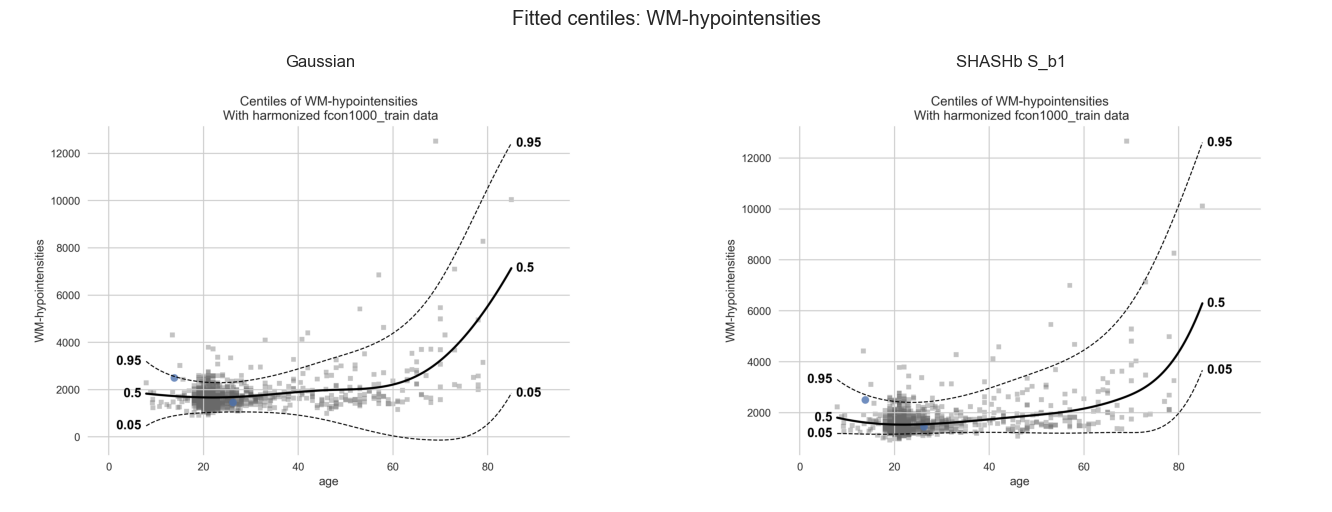

In [42]:
# Side-by-side centile curves: pick the hardest feature
# This recreates Figure 6 from the paper for our small dataset.

import os
import matplotlib.pyplot as plt

feature_to_compare = "WM-hypointensities"

for model_obj, title in [(gaussian_model, "Gaussian"), (model, "SHASHb S_b1")]:
    save_path = f"/tmp/centile_plots/{title}"
    os.makedirs(save_path, exist_ok=True)
    plot_centiles_advanced(
        model_obj,
        centiles=[0.05, 0.5, 0.95],
        scatter_data=train,
        harmonize_data=True,
        show_legend=False,
        save_dir=save_path,
        show_other_data=True
    )
    plt.close("all")

# display side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title in zip(axes, ["Gaussian", "SHASHb S_b1"]):
    folder = f"/tmp/centile_plots/{title}"
    files = os.listdir(folder)
    print(f"{title}: {files}")  # check filenames
    saved = [f for f in files if feature_to_compare in f]
    if saved:
        img = plt.imread(os.path.join(folder, saved[0]))
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"Fitted centiles: {feature_to_compare}", y=1.02)
plt.tight_layout()
plt.show()

**Questions for reflection:**

1. For which features does the SHASH model improve the most over Gaussian? For which features is the improvement smallest?
2. Does the lower centile (5th percentile) stay positive for volume measures? This is a basic sanity check.
3. Look at the skew and kurtosis statistics. Which model gets closer to 0? Is the improvement larger for "hard" or "easy" phenotypes?
4. What would you need to change to get the S_b2 model — and for which features in this dataset do you think it would help?

## Advanced: Plot the results

The PCNtoolkit offers are a number of different plotting functions:
1. plot_centiles: Plot the predicted centiles for a model on top of harmonized scatter data. 
2. plot_centiles_advanced: a more advanced version of plot_centiles, with more configuration options, coloring, and conditionals
3. plot_qq: Plot the QQ-plot of the predicted Z-scores
4. plot_ridge: Plot density plots of the predicted Z-scores

Let's start with the centiles.

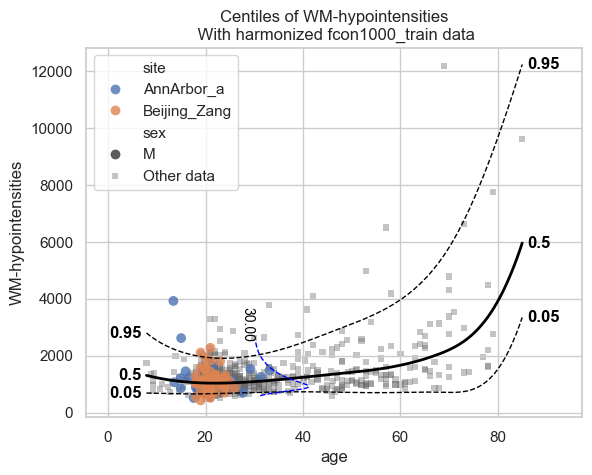

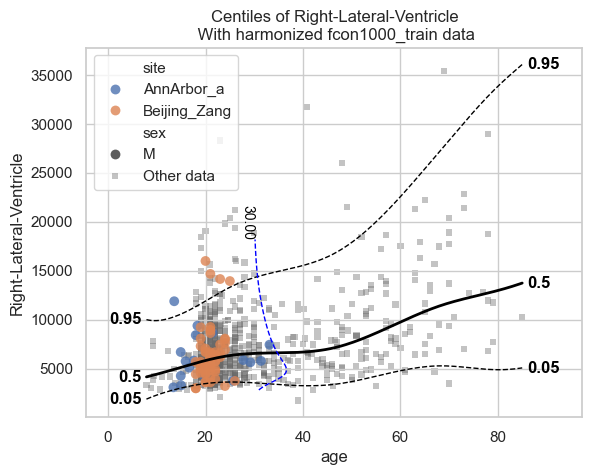

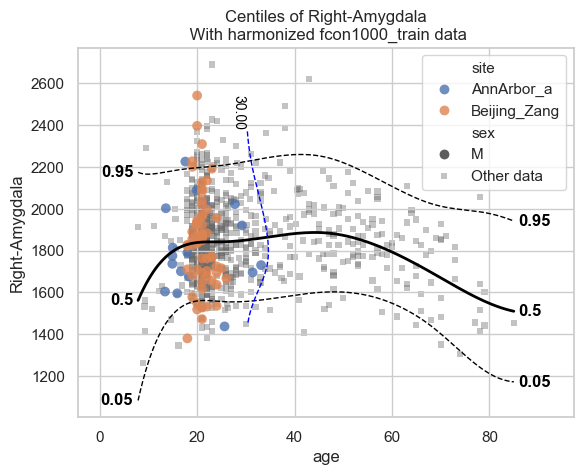

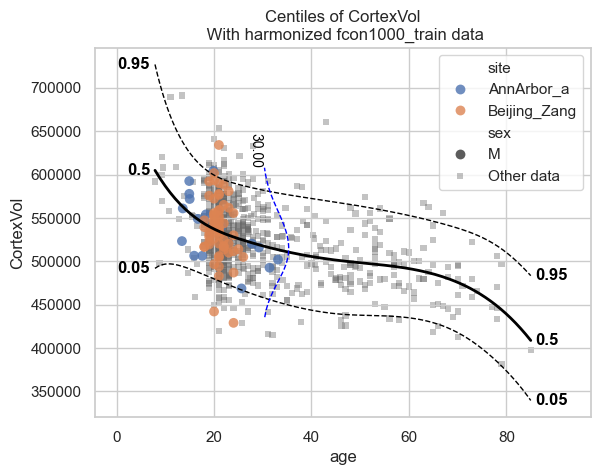

In [17]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=train,  # Scatter this data along with the centiles
    batch_effects={"site": ["Beijing_Zang", "AnnArbor_a"], "sex": ["M"]},  # Highlight these groups
    show_other_data=True,  # scatter data not in those groups as smaller black circles
    harmonize=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
    conditionals=[30]
)

Now let's see the qq plots

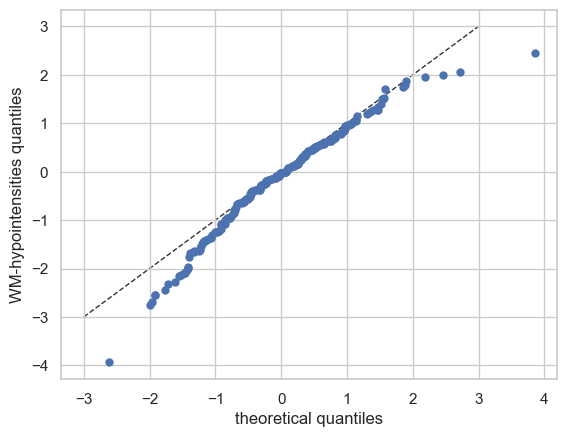

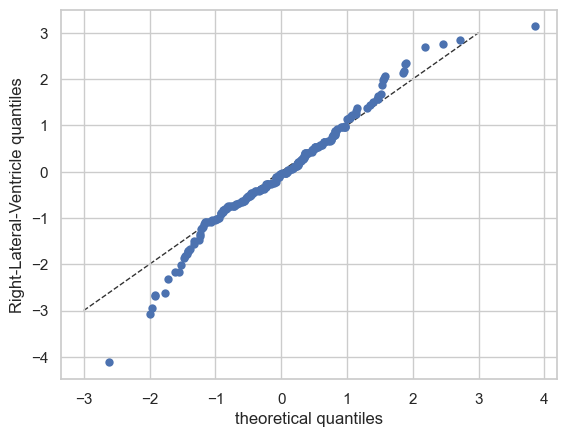

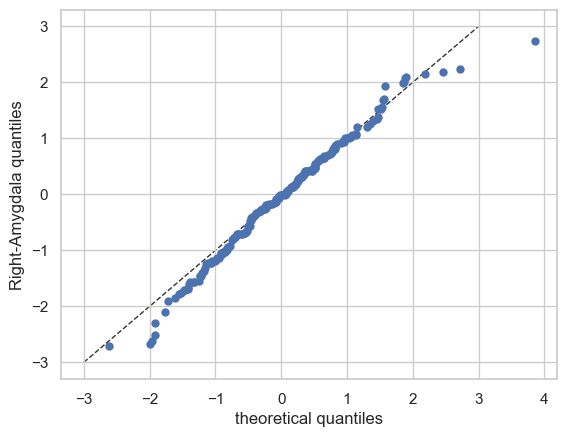

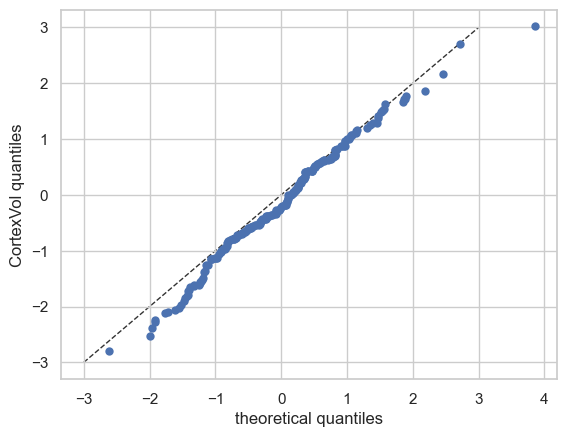

In [9]:
plot_qq(test, plot_id_line=True)

We can also split the QQ plots by batch effects:

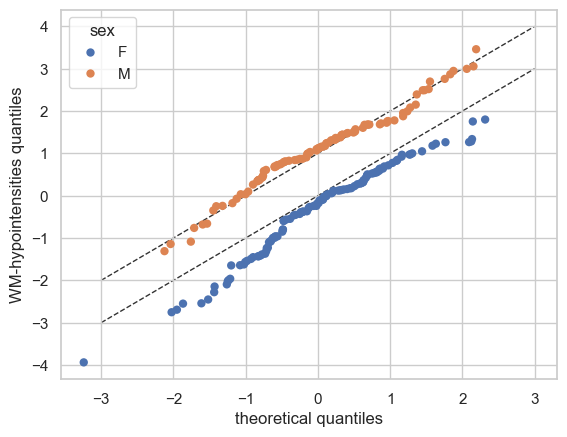

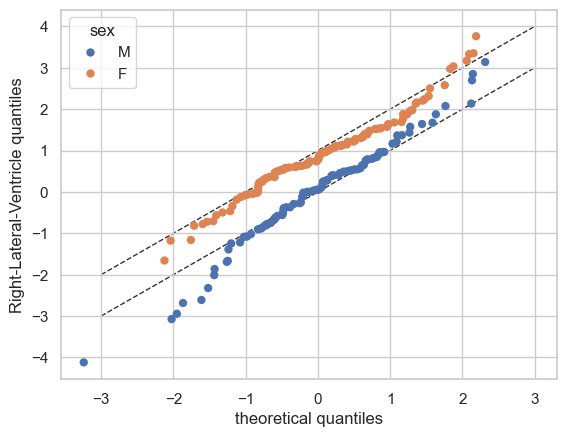

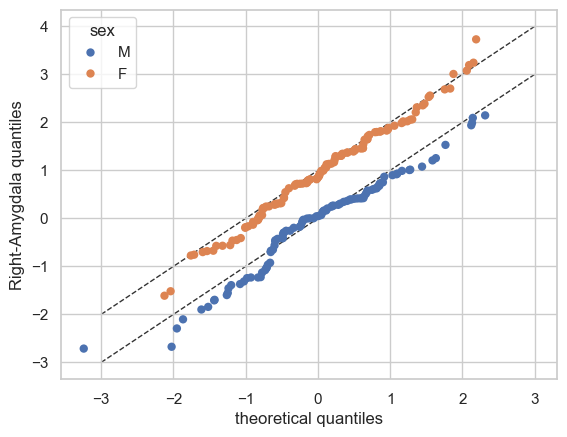

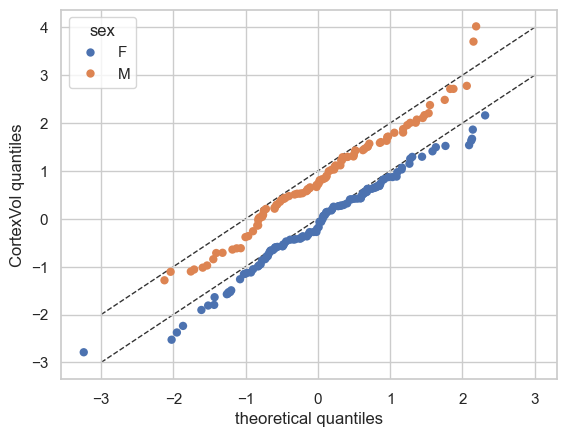

In [10]:
plot_qq(test, plot_id_line=True, hue_data="sex", split_data="sex")
sns.set_theme(style="darkgrid", rc={"axes.facecolor": (0, 0, 0, 0)})

And finally the ridge plot:

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top mar

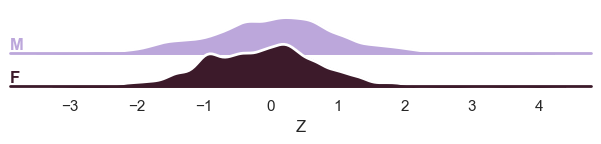

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top mar

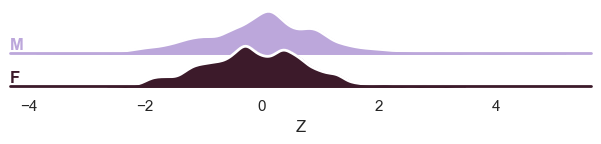

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top mar

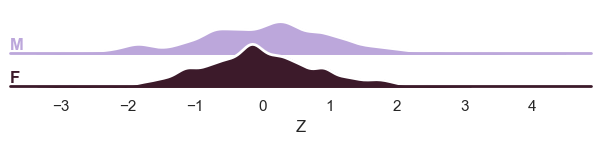

/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/Users/johannabayer/anaconda3/envs/pcntoolkit_p13/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top mar

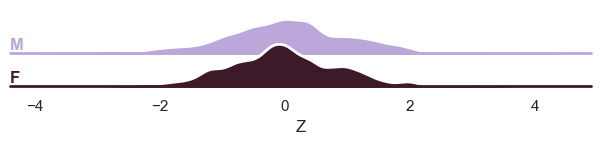

In [18]:
plot_ridge(
    train, "Z", split_by="sex"
)  # We can also show the 'Y' variable, and that will show the marginal distribution of the response variable, per batch effect.

Evaluation statistcs are stored in the NormData object:

In [19]:
display(train.get_statistics_df())
display(test.get_statistics_df())

statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.519158,0.010719,0.057418,-11.208155,1.072417,0.519138,36154.130978,0.710267,2.877842e-133,0.480862,0.995140
Right-Amygdala,0.383249,0.013457,0.088627,-5.738165,1.182031,0.383121,192.426760,0.599975,2.096802e-85,0.616879,0.995658
Right-Lateral-Ventricle,0.214729,0.013503,0.399664,-8.643727,1.031097,0.212906,3415.847750,0.371617,1.282156e-29,0.787094,0.987524
WM-hypointensities,0.352123,0.015128,0.320951,-7.437738,0.686481,0.351329,657.777294,0.488338,7.392066e-53,0.648671,0.986365


statistic,EXPV,MACE,MAPE,MSLL,NLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW
response_vars,,,,,,,,,,,
CortexVol,0.420982,0.025926,0.063509,-11.114493,1.103067,0.412896,37509.331443,0.642463,1.545115e-26,0.587104,0.994712
Right-Amygdala,0.290545,0.014815,0.094863,-5.655117,1.227409,0.289549,198.871678,0.506638,1.744087e-15,0.710451,0.991558
Right-Lateral-Ventricle,0.204278,0.050926,0.421639,-8.340823,1.349683,0.203516,3490.475447,0.265320,7.889095e-05,0.796484,0.889695
WM-hypointensities,0.360051,0.037037,0.341827,-7.026159,0.798391,0.357004,485.317625,0.492443,1.354270e-14,0.642996,0.967340


## What's next?

Now we have a normative hierarchical Bayesian regression model, we can use it to:

- Make predictions on new data
- Harmonize data, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
- Synthesize new data
- Extend the model using data from new batches

### Predicting

In [20]:
model.predict(test)

<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, statistic: 11, centile: 5)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * statistic          (statistic) <U8 352B 'EXPV' 'MACE' ... 'SMSE' 'ShapiroW'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.5154 ... -...
    logp               (observations, response_vars) float64 7kB -1.615 ... -...
    Yhat               (observations, response_vars) float64 7kB 2.371e+03 .....
    statistics         (response_vars, statistic) float64 352B 0.3919 ... 0.995
    Y_harmonized       (observations, response_vars) float64 7kB 3.224e+03 .....
    centiles           (centile, observations, response_vars) float64 35kB 1....
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): [np.str_('F'), np.str_('...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'mean': np.float64(28.2...
    batch_effect_covariate_ranges:  {np.str_('sex'): {np.str_('F'): {np.str_(...

### Harmonize

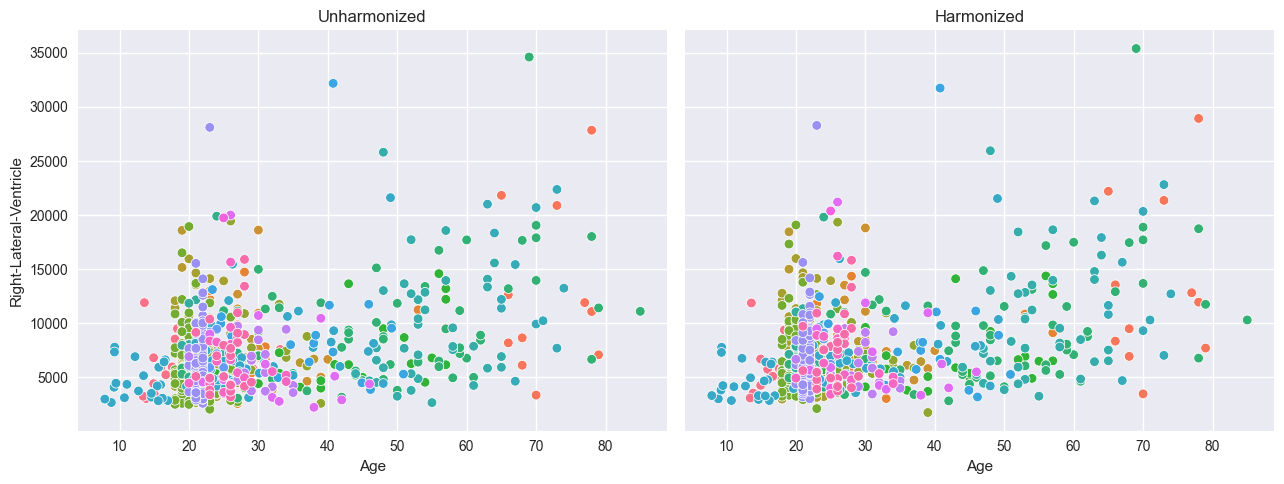

In [21]:
# Harmonizing is also easy:
reference_batch_effect = {
    "site": "Beijing_Zang",
    "sex": "M",
}  # Set a pseudo-batch effect. I.e., this means 'pretend that all data was from this site and sex'

# model.harmonize(train, reference_batch_effect=reference_batch_effect)  # <- easy

plt.style.use("seaborn-v0_8")
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

### Synthesize

Our models can synthesize new data that follows the learned distribution. 

Not only the distribution of the response variables given a covariate is learned, but also the ranges of the covariates _within_ each batch effect. So if we have fitted a model on a number of sites, and subjects from A have an age between 10 and 20, then the synthesized pseudo-subjects from site A will also have an age between 10 and 20.

Not only that, but we also sample the batch effects in the frequency of the batch effects in the original data. So if the train data contained twice as many subjects from site A as site B, then the synthesized pseudo-subjects will also have twice as many subjects from site A as site B.

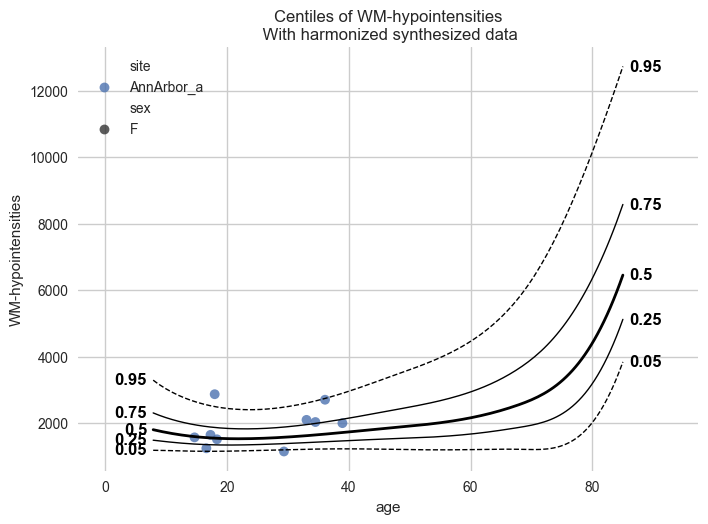

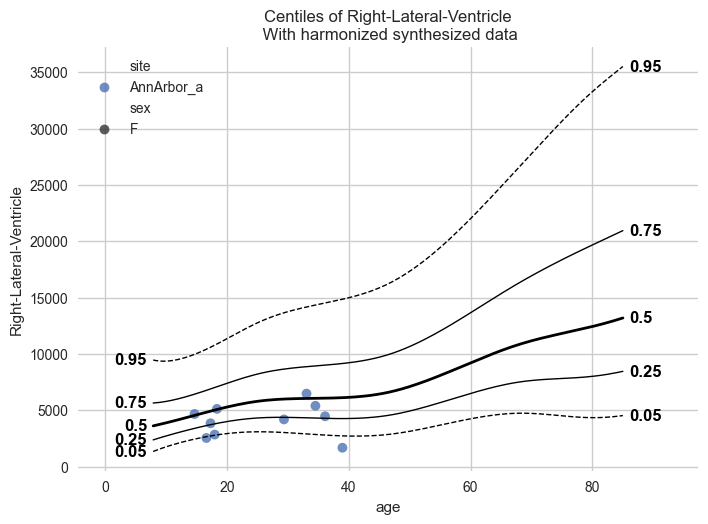

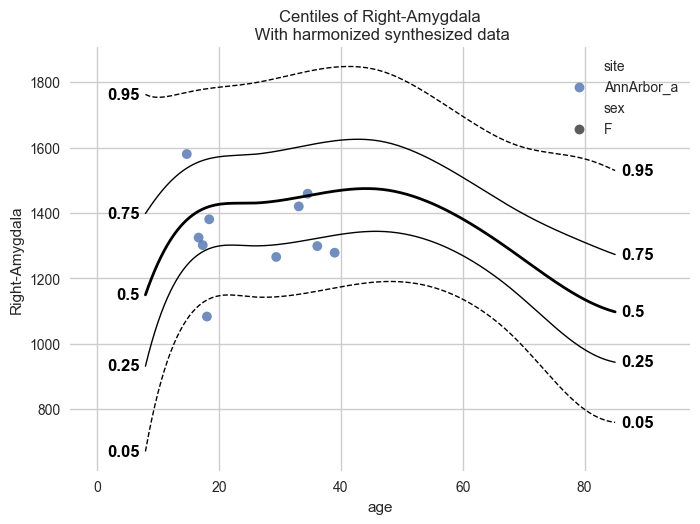

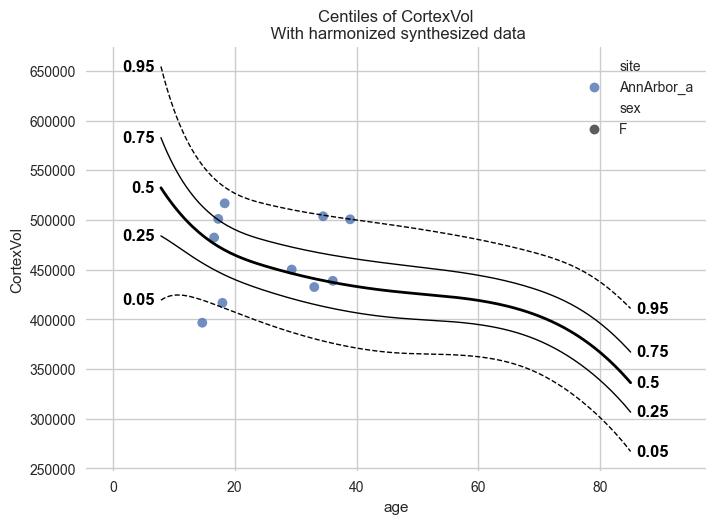

In [22]:
# Generate 10000 synthetic datapoints from scratch
synthetic_data = model.synthesize(covariate_range_per_batch_effect=True, n_samples=1000)  # <- also easy
# Show the synthetic data along with the centiles
plot_centiles_advanced(
    model,
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic_data,
)

In [23]:
# Synthesize new Y data for existing X data
new_test_data = test.copy()

# Remove the Y data, this way we will synthesize new Y data for the existing X data
if hasattr(new_test_data, "Y"):
    del new_test_data["Y"]

synthetic = model.synthesize(new_test_data)  # <- will fill in the missing Y data

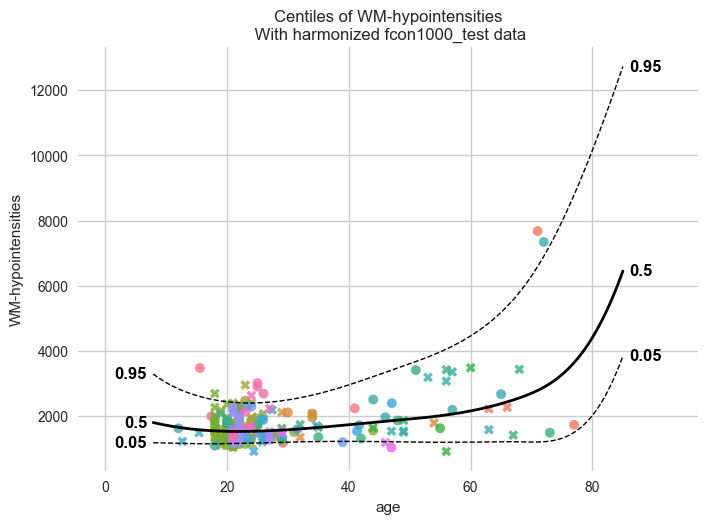

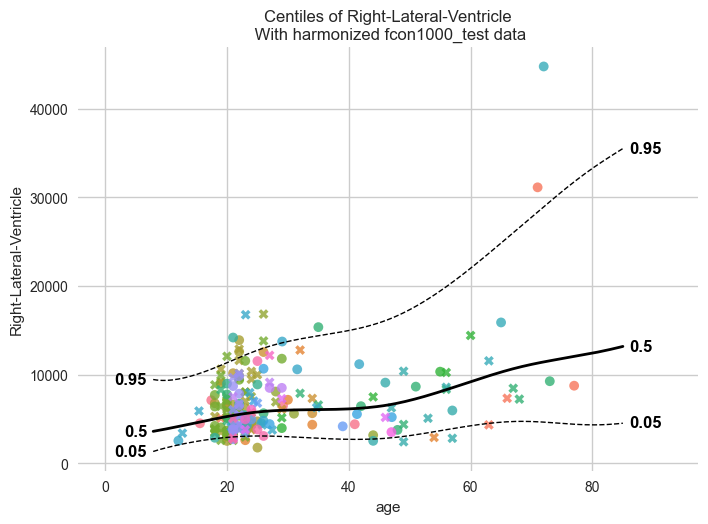

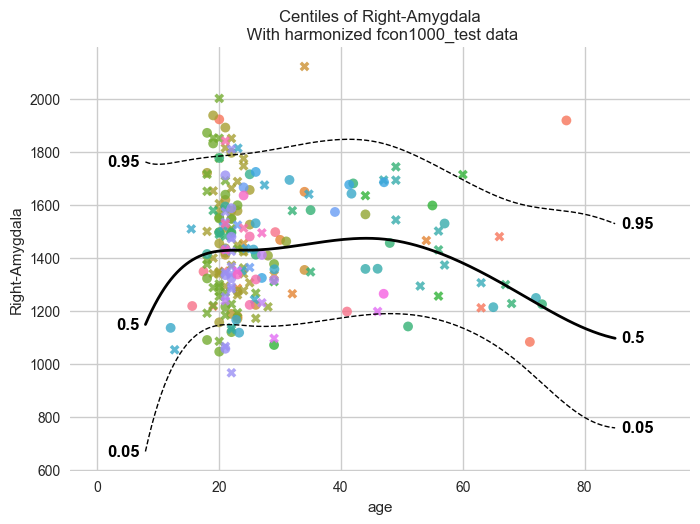

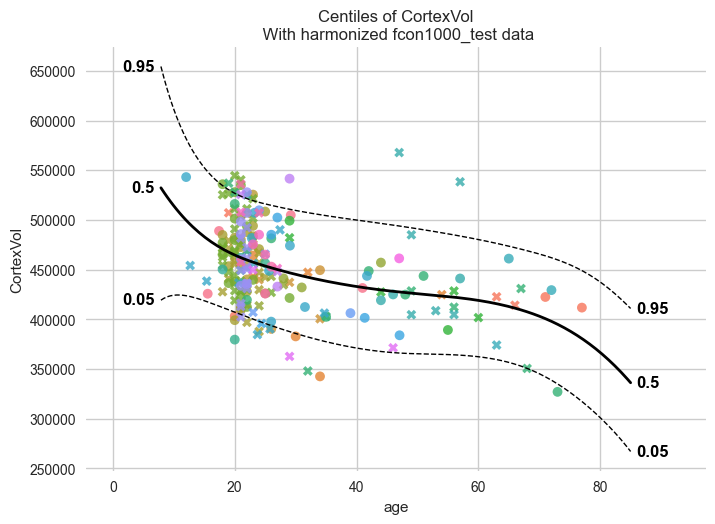

In [24]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot arbitrary centiles
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic,  # Scatter the train data points
    batch_effects="all",  # You can set this to "all" to show all batch effects
    show_other_data=False,  # Show data points that do not match any batch effects
    show_centile_labels=True,
    harmonize_data=True,  # Set this to False to see the difference
    show_legend=False,  # Don't show the legend because it crowds the plot
)

## Next steps

Please see the other tutorials for more examples, and we also recommend you to read the documentation! As this toolkit is still in development, the documentation may not be up to date. If you find any issues, please let us know! 

Also, feel free to contact us on Github if you have any questions or suggestions.

Have fun modeling!

### Bonus content

Here is another model configuration using a SHASH likelihood, but this one also has a linear regression in epsilon and delta. If you have a feature that is heavily skewed and for which the skewness also changes with the covariates, this is the model for you:

In [18]:
# Here's a model with a SHASHb likelihood, with a linear regression in all four parameters, so including epsilon and delta.
# This is a very flexible model, but it will also take a lot longer to run.
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(3.0, 1.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)

delta = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(
        0.0,
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb2_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)